# Trader Performance vs Market Sentiment

This notebook analyzes how Bitcoin Fear/Greed sentiment relates to trader behavior and performance on Hyperliquid.

## Notebook flow

1. Load the datasets
2. Check data quality
3. Build account-day metrics
4. Compare performance across sentiment regimes
5. Segment traders
6. Summarize findings and strategy ideas

In [14]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from analysis import (
    CHART_DIR,
    TABLE_DIR,
    ensure_dirs,
    load_data,
    build_data_quality,
    build_daily_account,
    build_account_segments,
    sentiment_performance_table,
    segment_performance_table,
    top_accounts_table,
    build_key_findings,
    make_charts,
    save_table,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [15]:
raw_sentiment = pd.read_csv('data/sentiment.csv')
raw_trader = pd.read_csv('data/trader_data.csv')
sentiment_shape = raw_sentiment.shape
trader_shape = raw_trader.shape

sentiment, trader = load_data()

raw_sentiment['date'] = pd.to_datetime(raw_sentiment['date'])
raw_trader['Timestamp IST'] = pd.to_datetime(raw_trader['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
raw_trader['trade_date'] = raw_trader['Timestamp IST'].dt.normalize()

print('Sentiment shape:', sentiment_shape)
print('Trader shape:', trader_shape)

Sentiment shape: (2644, 4)
Trader shape: (211224, 16)


## Data quality checks

The assignment explicitly asks for row/column counts, missing values, duplicates, and daily date alignment.

In [16]:
data_quality = build_data_quality(raw_sentiment, raw_trader)
data_quality.loc[data_quality['dataset'].eq('sentiment'), 'columns'] = sentiment_shape[1]
data_quality.loc[data_quality['dataset'].eq('trader'), 'columns'] = trader_shape[1]
data_quality

,dataset,rows,columns,duplicate_rows,missing_cells,date_min,date_max
0,sentiment,2644,4,0,0,2018-02-01,2025-05-02
1,trader,211224,16,0,0,2023-05-01,2025-05-01


In [17]:
matched_rows = trader['trade_date'].isin(set(sentiment['date'])).sum()
overlap_summary = pd.DataFrame({
    'metric': ['sentiment_date_min', 'sentiment_date_max', 'trader_date_min', 'trader_date_max', 'matched_trader_rows'],
    'value': [
        str(sentiment['date'].min().date()),
        str(sentiment['date'].max().date()),
        str(trader['trade_date'].min().date()),
        str(trader['trade_date'].max().date()),
        int(matched_rows),
    ]
})
overlap_summary

,metric,value
0,sentiment_date_min,2018-02-01
1,sentiment_date_max,2025-05-02
2,trader_date_min,2023-05-01
3,trader_date_max,2025-05-01
4,matched_trader_rows,211218


## Feature engineering

I aggregate the trade log to the account-day level and join daily sentiment labels. This gives a clean unit for comparing behavior and performance across market regimes.

In [18]:
daily_account = build_daily_account(sentiment, trader)
account_segments = build_account_segments(daily_account)

daily_account.head()

,Account,trade_date,daily_pnl,total_fee,trades,realized_trades,profitable_trades,losing_trades,avg_trade_size_usd,median_trade_size_usd,gross_notional_usd,avg_abs_start_position,buy_trades,sell_trades,long_flag_count,short_flag_count,trade_win_rate,long_short_ratio,net_pnl_after_fees,active_day,classification,value,sentiment_bucket
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.00,167.80,177,0,0,0,"5,089.72","2,736.64","900,880.13",153.89,0,177,0,177,NaN,0.00,-167.80,1,Extreme Greed,76.00,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.00,67.88,68,0,0,0,"7,976.66","2,340.00","542,413.18",496.00,0,68,0,68,NaN,0.00,-67.88,1,Extreme Greed,90.00,Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.00,94.94,40,0,0,0,"23,734.50","3,594.51","949,380.00",456.89,0,40,0,40,NaN,0.00,-94.94,1,Extreme Greed,83.00,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,"-21,227.00",33.82,12,12,0,12,"28,186.67","29,307.14","338,240.00",634.75,12,0,0,12,0.00,0.00,"-21,260.82",1,Extreme Greed,94.00,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,"1,603.10",104.62,27,12,12,0,"17,248.15","8,898.30","465,700.00",513.00,12,15,0,27,1.00,0.00,"1,498.48",1,Extreme Greed,79.00,Greed


In [19]:
perf_table = sentiment_performance_table(daily_account)
perf_table

,sentiment_bucket,account_days,total_net_pnl,avg_daily_pnl,median_daily_pnl,daily_win_rate,avg_trade_win_rate,avg_trades,avg_trade_size_usd,avg_gross_notional_usd,avg_fee,avg_abs_start_position
0,Fear,790,"3,979,920.11","5,037.87",104.55,0.59,0.84,105.36,"8,529.86","756,720.32",147.27,"80,173.56"
1,Greed,1174,"4,775,171.23","4,067.44",235.92,0.63,0.86,76.91,"5,954.63","351,829.35",76.77,"52,247.71"
2,Neutral,376,"1,253,546.41","3,333.90",151.37,0.62,0.84,100.23,"6,963.69","479,367.19",104.72,"78,033.22"


## Trader segments

To make the analysis actionable, traders are split into:

- High activity vs Low activity
- Large size vs Small size
- Consistent winners vs Inconsistent traders

In [20]:
segment_table = segment_performance_table(daily_account, account_segments)
segment_table

,segment_type,segment_label,sentiment_bucket,account_days,avg_net_pnl,median_net_pnl,avg_trades,positive_day_rate
0,activity_segment,High activity,Fear,387,"7,700.67",259.35,179.88,0.69
1,activity_segment,High activity,Greed,481,"4,843.06",583.36,132.22,0.77
2,activity_segment,High activity,Neutral,166,"3,976.02",325.37,169.28,0.77
3,activity_segment,Low activity,Fear,403,"2,480.80",0.00,33.81,0.50
4,activity_segment,Low activity,Greed,693,"3,529.09",60.95,38.53,0.54
5,activity_segment,Low activity,Neutral,210,"2,826.32",21.99,45.64,0.51
6,consistency_segment,Consistent winners,Fear,488,"5,795.93",183.52,128.90,0.69
7,consistency_segment,Consistent winners,Greed,764,"2,736.62",497.72,91.70,0.76
8,consistency_segment,Consistent winners,Neutral,241,"1,520.32",295.35,117.00,0.75
9,consistency_segment,Inconsistent,Fear,302,"3,812.93",-0.11,67.33,0.43


In [8]:
top_accounts = top_accounts_table(account_segments)
top_accounts.head(10)

,Account,active_days,total_trades,avg_daily_trades,avg_trade_size_usd,total_net_pnl,avg_daily_pnl,profitable_days,losing_days,avg_realized_win_rate,profitable_day_ratio,activity_segment,size_segment,consistency_segment
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,256,14733,57.55,"4,495.50","2,127,387.28","8,310.11",120,134,0.80,0.47,Low activity,Small size,Inconsistent
0,0x083384f897ee0f19899168e3b1bec365f52a9012,24,3818,159.08,"33,569.10","1,592,824.51","66,367.69",16,7,0.77,0.67,High activity,Large size,Consistent winners
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,28,21192,756.86,"4,528.36","931,567.10","33,270.25",21,6,0.95,0.75,High activity,Small size,Consistent winners
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,131,40184,306.75,"1,760.54","822,727.65","6,280.36",104,26,0.81,0.79,High activity,Small size,Consistent winners
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,39,12236,313.74,"27,603.85","763,997.91","19,589.69",21,17,0.87,0.54,High activity,Large size,Inconsistent
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,58,4356,75.10,"16,024.72","669,721.06","11,546.91",38,20,0.91,0.66,High activity,Large size,Consistent winners
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,19,1590,83.68,"9,367.30","427,804.13","22,516.01",4,15,0.53,0.21,High activity,Large size,Inconsistent
9,0x430f09841d65beb3f27765503d0f850b8bce7713,28,1237,44.18,"2,525.95","415,794.87","14,849.82",7,8,1.00,0.25,Low activity,Small size,Inconsistent
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,66,1430,21.67,"4,840.92","402,721.49","6,101.84",17,49,0.80,0.26,Low activity,Large size,Inconsistent
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,146,9893,67.76,"3,354.21","376,500.15","2,578.77",132,14,0.88,0.90,High activity,Small size,Consistent winners


## Charts

The same charts used in the final write-up are generated below.

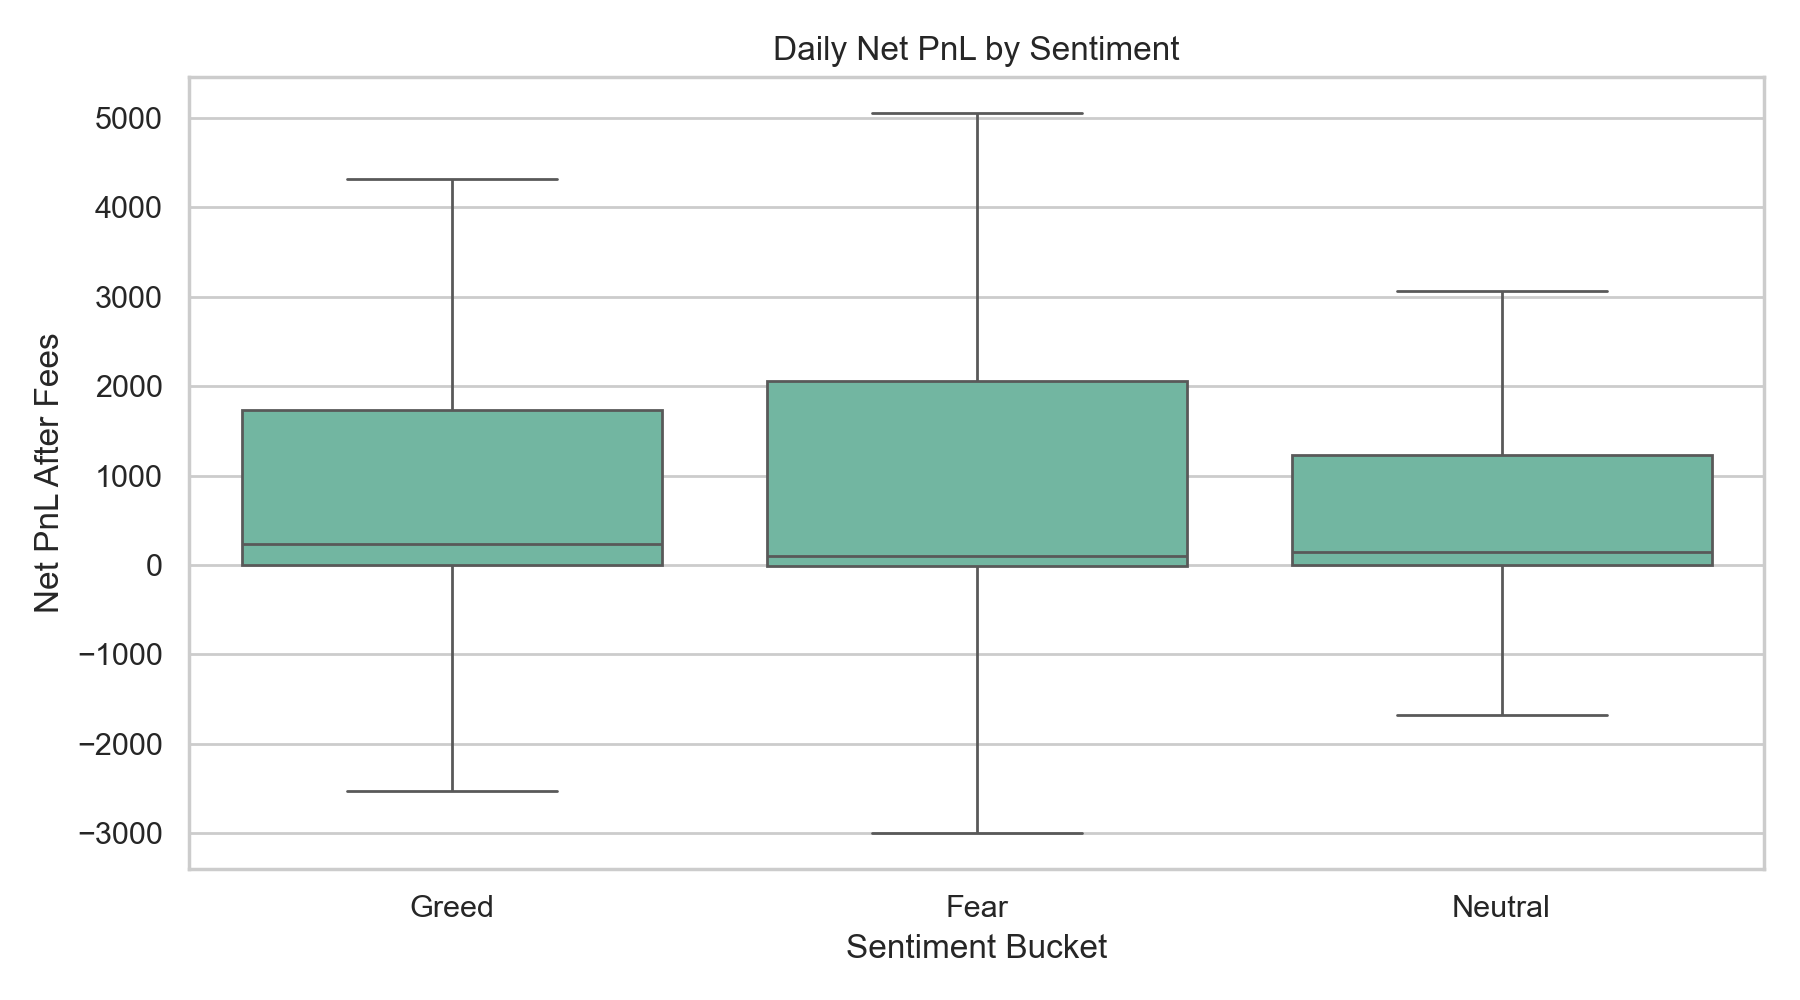

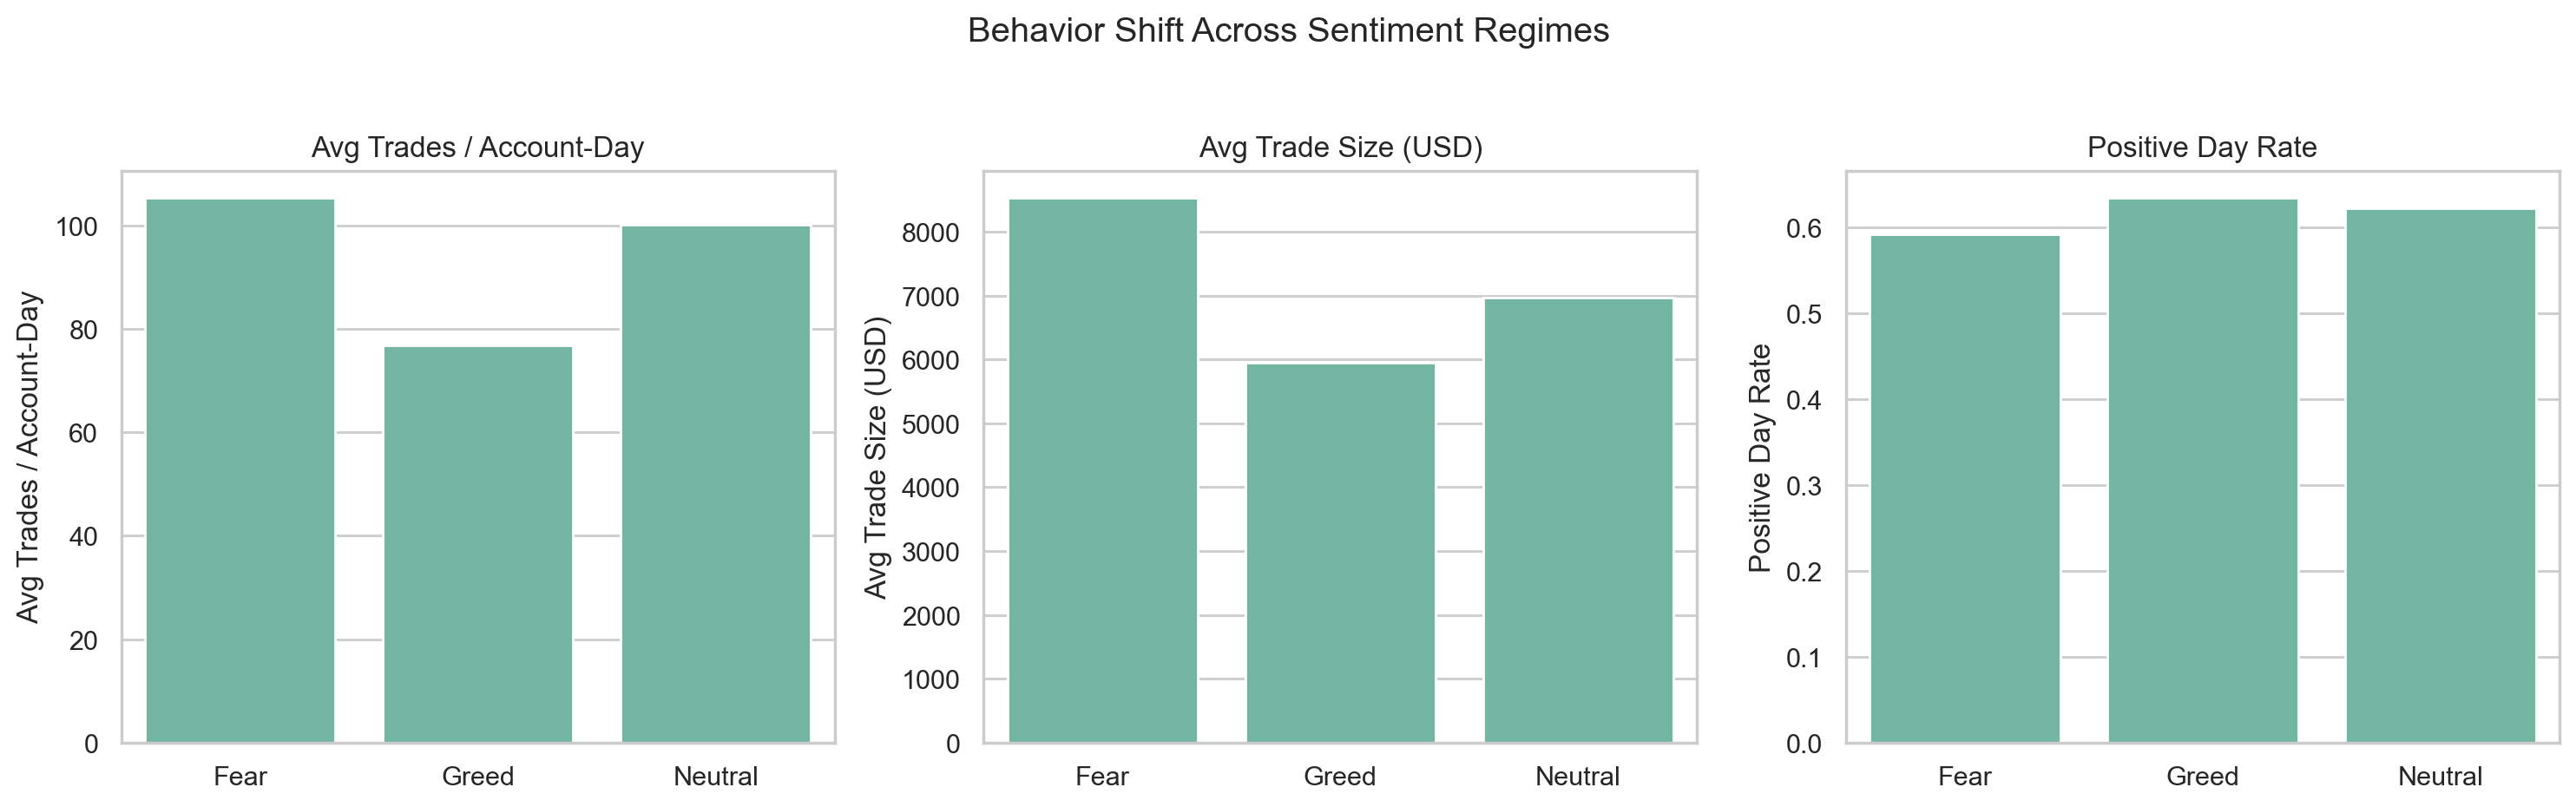

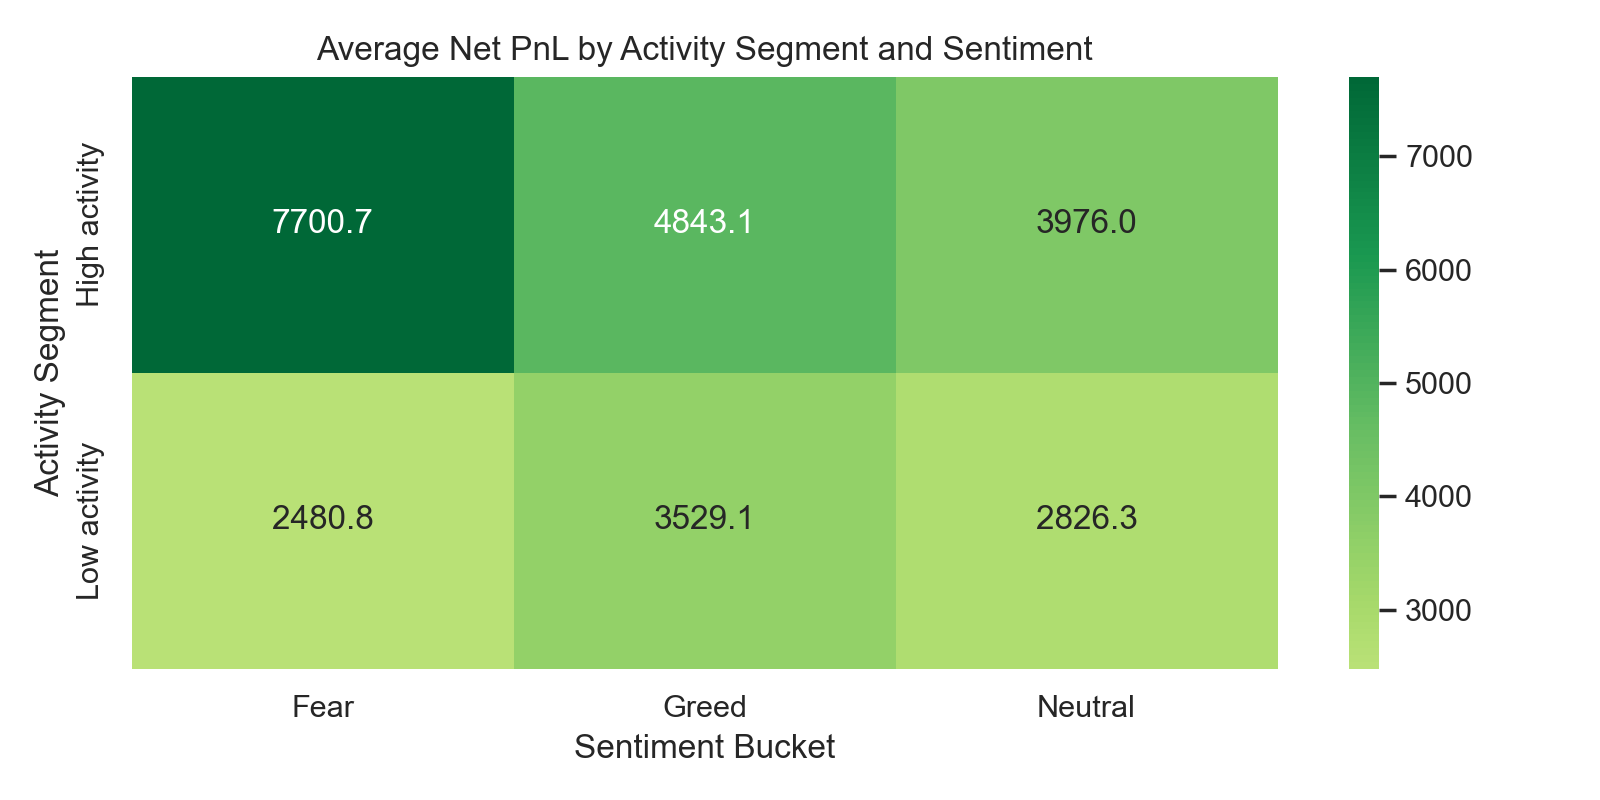

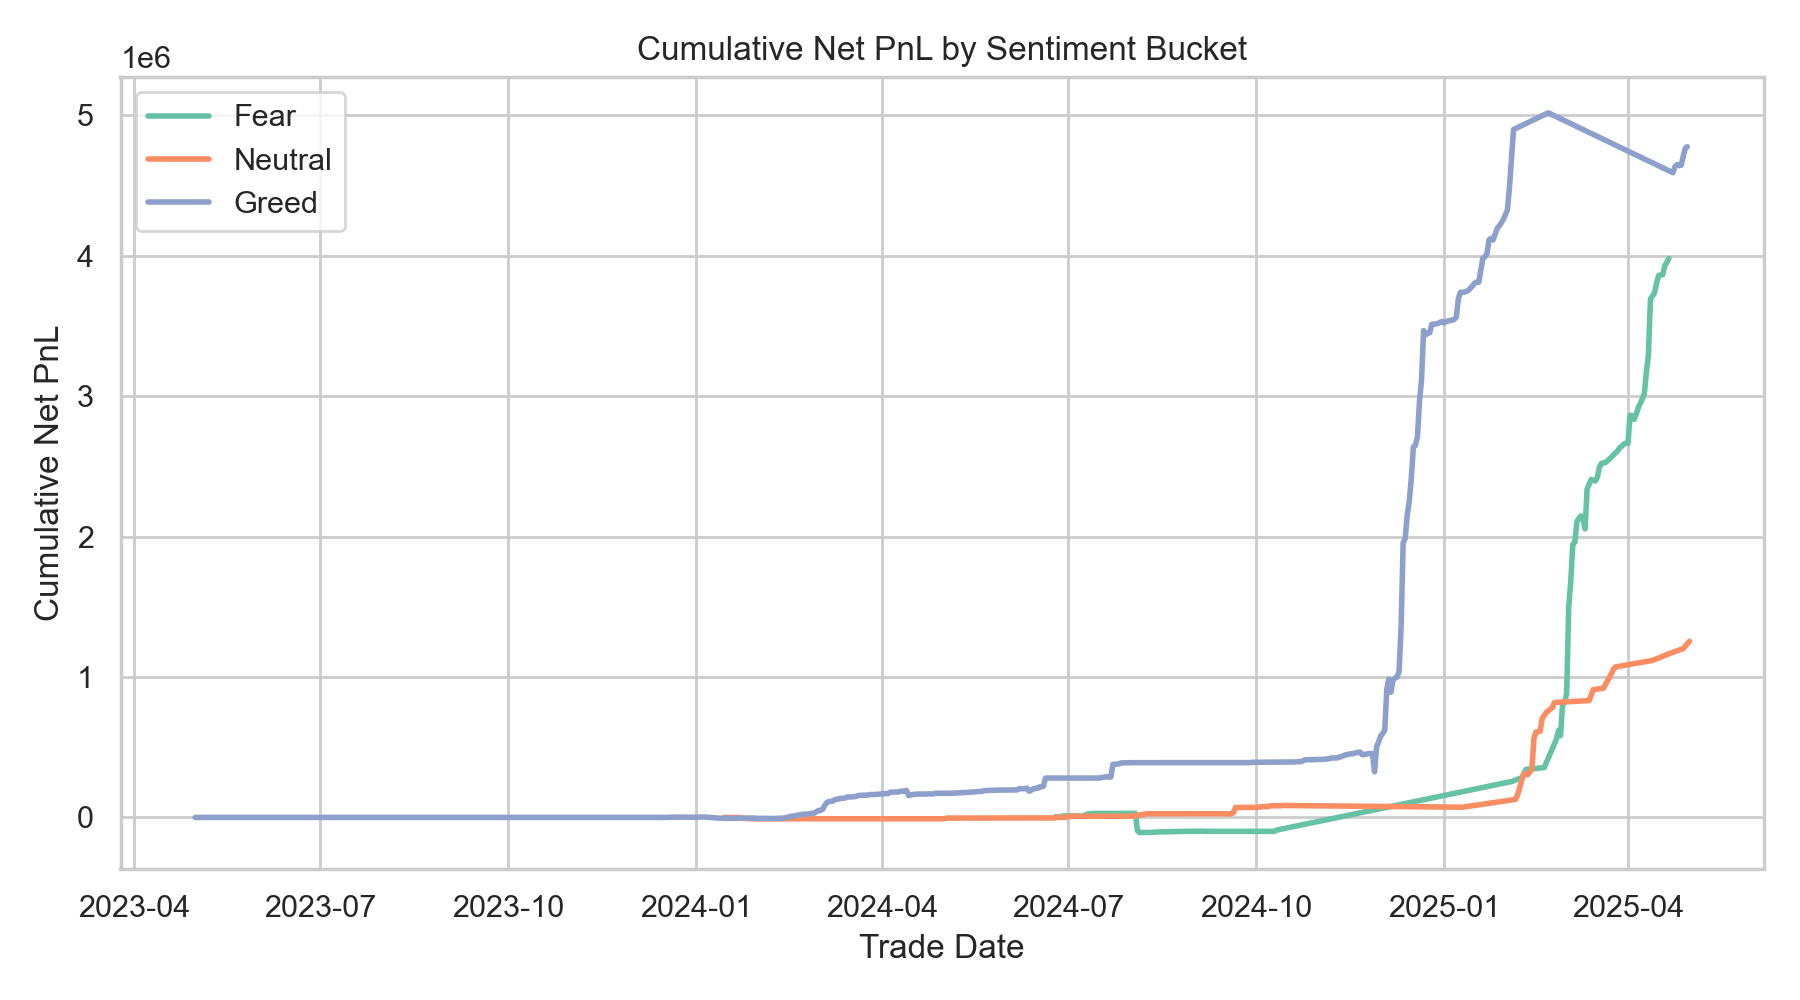

In [21]:
ensure_dirs()
make_charts(daily_account, perf_table, segment_table)

for chart_name in [
    'daily_pnl_by_sentiment.png',
    'behavior_shift_by_sentiment.png',
    'activity_segment_heatmap.png',
    'cumulative_pnl_by_sentiment.png',
]:
    display(Image(filename=str(CHART_DIR / chart_name)))

## Key findings

These summary statements are derived directly from the generated tables.

In [23]:
findings = build_key_findings(perf_table, segment_table, top_accounts)
findings

,finding,value,unit
0,Average net PnL gap: Fear minus Greed,970.44,USD per account-day
1,Trade frequency gap: Greed minus Fear,-28.45,trades per account-day
2,Average trade size gap: Greed minus Fear,"-2,575.23",USD
3,High activity traders beat low activity trader...,"5,219.87",USD per account-day
4,Top account total net PnL,"2,127,387.28",USD
5,Positive-day rate gap: Greed minus Fear,0.04,share


### Business interpretation

- Fear days delivered higher average net PnL per account-day than Greed days.
- Greed days were steadier: they had a higher positive-day rate and a better median daily PnL.
- Traders became more aggressive on Fear days, with more trades and larger average trade sizes.
- High-activity traders handled Fear regimes best, while large-size traders were weaker on Greed days.
- This suggests that stressed markets reward disciplined active execution, while Greed regimes favor smaller and more selective risk-taking.

## Strategy ideas

1. On Fear days, allow higher activity only for already-proven active traders because this segment captured the strongest upside.
2. On Greed days, reduce position size for large-size traders and favor more selective entries because oversized risk hurt median outcomes.

In [24]:
save_table(data_quality, 'data_quality')
save_table(daily_account, 'daily_account_metrics')
save_table(account_segments, 'account_segments')
save_table(perf_table, 'sentiment_performance')
save_table(segment_table, 'segment_performance')
save_table(top_accounts, 'top_accounts')
save_table(findings, 'key_findings')

print('Notebook outputs saved to:', TABLE_DIR)
print('Charts saved to:', CHART_DIR)

Notebook outputs saved to: C:\skills\Internships\intershalla task intership selection\Trader Performance vs Market Sentiment (Primeai)\outputs\tables
Charts saved to: C:\skills\Internships\intershalla task intership selection\Trader Performance vs Market Sentiment (Primeai)\outputs\charts
